# **In this notebook we are making a neural network from scratch that predicts the XOR gate.**

## As we know that XOR doesnot show linear relationship we are making it to understand the logic.

### Model has 100% accuracy and very minimal error

In [207]:
import numpy as np
import matplotlib.pyplot as plt

## **Preparing dataset**

In [208]:
X = np.array([[0,0],
             [0,1],
             [1,0],
             [0,0],
             [1,0],
             [0,0],
             [0,1]])
y= np.array([[0],
            [1],
            [1],
            [0],
            [1],
            [0],
            [1]])


# **Splitting dataset for training and testing**

In [209]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)


# **Neural Network class from scratch**


*   __init__ : function is used to initialize the layers in network, weights, bias, learning rate and iteration
*   __forward__ : function is used to calculate the value after multiplying input with weights and adding bias
* __train__: function is used to fit the model and adjust its weight and bias
* __predict__: function is used to predict the new target value



In [210]:
class NeuralNetwork:

  def __init__(self,input_layer,hidden_layer,output_layer,alpha=0.001,iteration=100000):

    self.weights=[
                  np.random.rand(input_layer,hidden_layer),
                  np.random.rand(hidden_layer,output_layer)
                  ]

    self.bias = [
        np.zeros(hidden_layer),
        np.zeros(output_layer)
        ]

    self.alpha = alpha

    self.iteration = iteration

  def forward(self,X_train,num):

    y = self.bias[num-1] +  X_train @ self.weights[num-1]

    return y

  def train(self,X_train,y_train):

    self.losses = np.array([])

    for i in range(self.iteration):

      y = self.forward(X_train,1)

      self.z = self.relu_function(y)

      final = self.forward(self.z,2)

      y_pred = self.sigmoid_function(final)

      self.loss = self.compute_loss(y_pred,y_train)

      self.losses = np.append(self.losses,self.loss)


      gradient_weight,gradient_bias = self.backward(X_train,y_train,y_pred)

      self.optimization(gradient_weight,gradient_bias)

    print("After training loss:",self.loss)
    print("Final prediction of model during training",y_pred)


  def compute_loss(self,y_pred,y_actual):

    loss = y_actual * np.log(y_pred) + (1-y_actual) * np.log(1-y_pred)

    return np.mean(-(1 * loss))

  def backward(self,X_train,y_train,y_pred):

    N = X_train.shape[0]

    first_term = (y_pred-y_train) @ self.weights[1].T

    db0 = np.mean(first_term  * self.relu_deriv,axis=0)

    dw0 = X_train.T @ (first_term * self.relu_deriv) / N

    db1 = np.mean(y_pred-y_train,axis=0)

    dw1 = self.z.T @ (y_pred-y_train)  / N

    return [dw0,dw1],[db0,db1]

  def relu_function(self,y):

    self.relu_deriv = np.where(y > 0, 1, 0)

    return np.maximum(y,0)


  def sigmoid_function(Self,z):

    final = 1 / (1+np.exp(z * -1))

    return final

  def optimization(self,gradient_weight,gradient_bias):

    self.weights[0] = self.weights[0] - self.alpha * gradient_weight[0]

    self.weights[1] = self.weights[1] - self.alpha * gradient_weight[1]

    self.bias[0] = self.bias[0] - self.alpha * gradient_bias[0]

    self.bias[1] = self.bias[1] - self.alpha * gradient_bias[1]


  def predict(self, X_test):

    y=self.forward(X_test,1)
    z=self.relu_function(y)
    final=self.forward(z,2)
    y_pred=self.sigmoid_function(final)

    return y_pred

  def visualize_loss(self):

    plt.title("Loss vs Iteration")
    plt.plot(np.arange(len(self.losses)),self.losses)
    plt.show()

# **Training the model**

In [211]:
nn = NeuralNetwork(2,2,1)

nn.train(X_train,y_train)

After training loss: 0.01585328465188989
Final prediction of model during training [[0.9970846 ]
 [0.99697686]
 [0.9970846 ]
 [0.04075856]
 [0.04075856]
 [0.99697686]]


# **Visualization of loss with respect to iteration**

## Loss is gradually decreasing

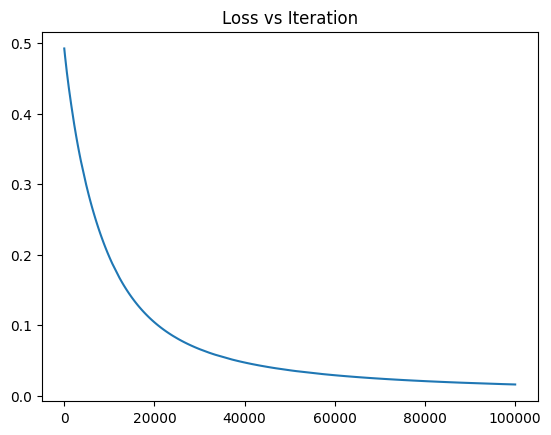

In [212]:
nn.visualize_loss()

# **Testing the model**

### The model showed incredible accuracy and loss

In [213]:
print("The testing dataset are:")
print("X_test:",X_test)
print("y_test:",y_test)


y_pred = nn.predict(X_test)

y_pred_class = (y_pred > 0.5).astype(int)
accuracy = np.mean(y_pred_class == y_test)
print("The accuracy of the model is ",accuracy)

print("The loss of the model is:",nn.compute_loss(y_pred,0))

print("The final prediction of the system is: ",y_pred[0][0])

The testing dataset are:
X_test: [[0 0]]
y_test: [[0]]
The accuracy of the model is  1.0
The loss of the model is: 0.0416120041347781
The final prediction of the system is:  0.04075810973352394
